# 🫁 Chest X-Ray Pneumonia Detection
## Notebook 03 — Model 2: VGG16 (Transfer Learning)
**Backbone:** VGG16 pretrained on ImageNet
**Strategy:** Phase 1 → Freeze base, train head | Phase 2 → Fine-tune last 4 layers
**Input Size:** 224 x 224 x 3
**Task:** Binary Classification — NORMAL vs PNEUMONIA

In [4]:
import os, time, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU Available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.21.0
GPU Available: False


In [5]:
BASE_DIR = '../data/chest_xray/chest_xray'
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
VAL_DIR    = os.path.join(BASE_DIR, 'val')
TEST_DIR   = os.path.join(BASE_DIR, 'test')

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 20
MODEL_NAME = 'vgg16'

os.makedirs('../models',  exist_ok=True)
os.makedirs('../outputs', exist_ok=True)
print('✅ Config set')

✅ Config set


In [7]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f'Class indices: {train_gen.class_indices}')
print(f'Train samples: {train_gen.samples}')
print(f'Val samples:   {val_gen.samples}')
print(f'Test samples:  {test_gen.samples}')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Train samples: 5216
Val samples:   16
Test samples:  624


In [8]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
cw = dict(enumerate(class_weights))
print(f'Class Weights: {cw}')

Class Weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [5]:
# Load VGG16 base — freeze all layers first
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

print(f'VGG16 total layers: {len(base_model.layers)}')
print(f'VGG16 parameters:   {base_model.count_params():,}')

# Add custom classification head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 28s 0us/step
VGG16 total layers: 19
VGG16 parameters:   14,714,688


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,880,065 (56.76 MB)

 Trainable params: 164,865 (644.00 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [6]:
cb_list = [
    callbacks.ModelCheckpoint(
        f'../models/{MODEL_NAME}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]
print('✅ Callbacks ready')

✅ Callbacks ready


In [7]:
print('=' * 50)
print('PHASE 1: Training head with frozen VGG16 base')
print('=' * 50)

start = time.time()

history1 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    class_weight=cw,
    callbacks=cb_list
)

print(f'Phase 1 complete ✅')

PHASE 1: Training head with frozen VGG16 base
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7931 - auc: 0.9139 - loss: 0.3973
Epoch 1: val_accuracy improved from None to 0.87500, saving model to ../models/vgg16.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 1074s 7s/step - accuracy: 0.8855 - auc: 0.9644 - loss: 0.2520 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 0.1502 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9356 - auc: 0.9837 - loss: 0.1600
Epoch 2: val_accuracy did not improve from 0.87500
163/163 ━━━━━━━━━━━━━━━━━━━━ 1089s 7s/step - accuracy: 0.9381 - auc: 0.9835 - loss: 0.1577 - val_accuracy: 0.6875 - val_auc: 1.0000 - val_loss: 0.5074 - learning_rate: 0.0010
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9459 - auc: 0.9863 - loss: 0.1477
Epoch 3: val_accuracy improved from 0.87500 to 0.93750, saving model to ../models/vgg16.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 1095s 7s/step - accuracy: 0.9467 - auc: 0.

In [9]:
from tensorflow.keras.applications import VGG16
import time

# ── Reload everything ──────────────────────────────
model = tf.keras.models.load_model('../models/vgg16.keras')

# Rebuild base model reference
base_model = VGG16(weights='imagenet', include_top=False,
                   input_shape=(224, 224, 3))

# ── Unfreeze last 4 layers ─────────────────────────
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

# ── Recompile ──────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# ── Callbacks ──────────────────────────────────────
cb_list = [
    callbacks.ModelCheckpoint(
        '../models/vgg16.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

# ── Phase 2 Training ───────────────────────────────
print('=' * 50)
print('PHASE 2: Fine-tuning last 4 layers of VGG16')
print('=' * 50)

start = time.time()

history2 = model.fit(
    train_gen,
    epochs=5,
    validation_data=val_gen,
    class_weight=cw,
    callbacks=cb_list
)

train_time = time.time() - start
print(f'\n⏱️  Phase 2 Training Time: {train_time/60:.2f} minutes')

PHASE 2: Fine-tuning last 4 layers of VGG16
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9629 - auc: 0.9928 - loss: 0.1112
Epoch 1: val_accuracy improved from None to 0.93750, saving model to ../models/vgg16.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 1078s 7s/step - accuracy: 0.9605 - auc: 0.9919 - loss: 0.1063 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.0767 - learning_rate: 1.0000e-05
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9612 - auc: 0.9926 - loss: 0.1020
Epoch 2: val_accuracy did not improve from 0.93750
163/163 ━━━━━━━━━━━━━━━━━━━━ 1137s 7s/step - accuracy: 0.9640 - auc: 0.9938 - loss: 0.0932 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.0837 - learning_rate: 1.0000e-05
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9622 - auc: 0.9921 - loss: 0.1033
Epoch 3: val_accuracy did not improve from 0.93750
163/163 ━━━━━━━━━━━━━━━━━━━━ 1120s 7s/step - accuracy: 0.9634 - auc: 0.9936 - loss: 0.0955 - val_accuracy: 0.93

In [11]:
# Combine both phases
acc   = history1.history['accuracy']     + history2.history['accuracy']
vacc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss  = history1.history['loss']         + history2.history['loss']
vloss = history1.history['val_loss']     + history2.history['val_loss']
phase1_end = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VGG16 — Training History (Phase 1 + Phase 2)', fontsize=14, fontweight='bold')

axes[0].plot(acc,  label='Train Acc', color='#3498db', linewidth=2)
axes[0].plot(vacc, label='Val Acc',   color='#e74c3c', linewidth=2)
axes[0].axvline(x=phase1_end - 1, color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(loss,  label='Train Loss', color='#3498db', linewidth=2)
axes[1].plot(vloss, label='Val Loss',   color='#e74c3c', linewidth=2)
axes[1].axvline(x=phase1_end - 1, color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'../outputs/{MODEL_NAME}_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved training curves')

NameError: name 'history1' is not defined

In [12]:
best_model = tf.keras.models.load_model(f'../models/{MODEL_NAME}.keras')

test_loss, test_acc, test_auc = best_model.evaluate(test_gen, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test AUC      : {test_auc:.4f}')
print(f'Test Loss     : {test_loss:.4f}')

y_pred_prob = best_model.predict(test_gen, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)
y_true      = test_gen.classes

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

Test Accuracy : 90.54%
Test AUC      : 0.9566
Test Loss     : 0.2825

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.83      0.87       234
   PNEUMONIA       0.90      0.95      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.89      0.90       624
weighted avg       0.91      0.91      0.90       624



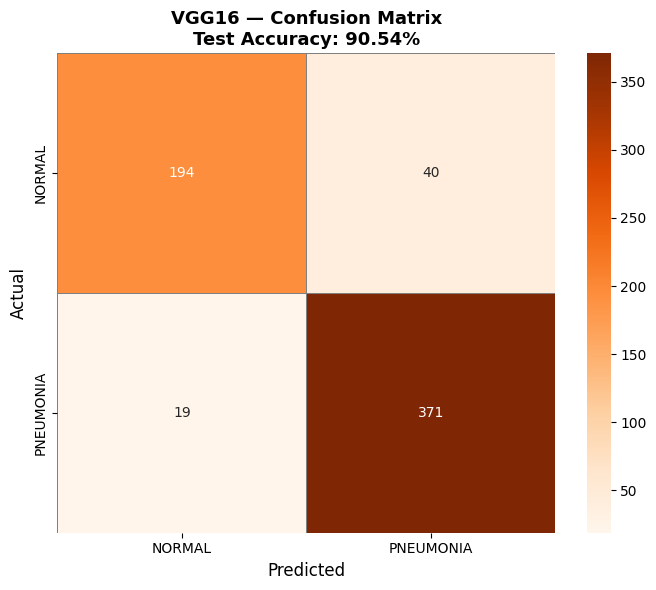

In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA'],
    linewidths=0.5, linecolor='gray'
)
plt.title(f'VGG16 — Confusion Matrix\nTest Accuracy: {test_acc*100:.2f}%',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig(f'../outputs/{MODEL_NAME}_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
results = {
    'model':          'VGG16',
    'accuracy':       round(test_acc * 100, 2),
    'auc':            round(float(test_auc), 4),
    'precision':      round(precision_score(y_true, y_pred) * 100, 2),
    'recall':         round(recall_score(y_true, y_pred) * 100, 2),
    'f1_score':       round(f1_score(y_true, y_pred) * 100, 2),
    'train_time_min': round(train_time / 60, 2)
}

with open(f'../outputs/{MODEL_NAME}_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('📦 Results saved!')
print(json.dumps(results, indent=2))
print('\n✅ Next: Notebook 04 — ResNet50')

📦 Results saved!
{
  "model": "VGG16",
  "accuracy": 90.54,
  "auc": 0.9566,
  "precision": 90.27,
  "recall": 95.13,
  "f1_score": 92.63,
  "train_time_min": 93.63
}

✅ Next: Notebook 04 — ResNet50
